## Part 1: Machine Learn the Dataset

In [1]:
import kagglehub
import pandas as pd

path = kagglehub.dataset_download("uciml/indian-liver-patient-records")

# First let's explore the data
df = pd.read_csv(path + "/indian_liver_patient.csv")

# Take a look at some rows and overall numbers across dataset
print("First 5 rows:")
display(df.head())
print("Last 5 rows:")
display(df.tail())
print("Shape:", df.shape,"\n")
print("Info:")
df.info()
print("\nSummary Statistics:")
display(df.describe())

# Missing values or duplicates
print("Null values: \n", df.isnull().sum()) # 4 nulls in Albumin_and_Globulin_Ratio column
print("\nDuplicate rows:", df.duplicated().sum()) # 13 duplicates

C:\Users\ferna\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


First 5 rows:


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


Last 5 rows:


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,2
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,1
582,38,Male,1.0,0.3,216,21,24,7.3,4.4,1.50,2


Shape: (583, 11) 

Info:
<class 'pandas.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    str    
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), str(1)
memory usage: 50.2 KB

Summary Statistics:


,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,579.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.947064,1.286449
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.319592,0.452490
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


Null values: 
 Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    4
Dataset                       0
dtype: int64

Duplicate rows: 13


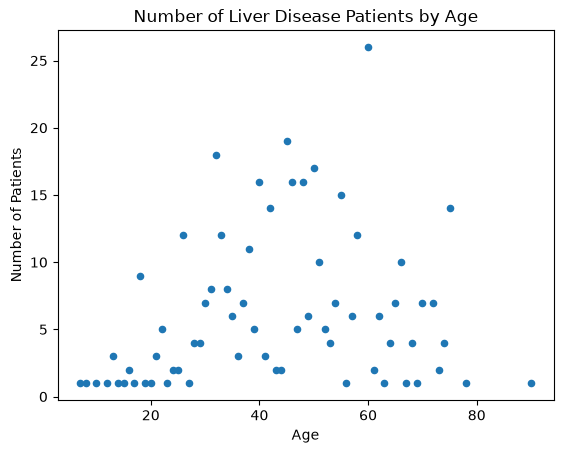

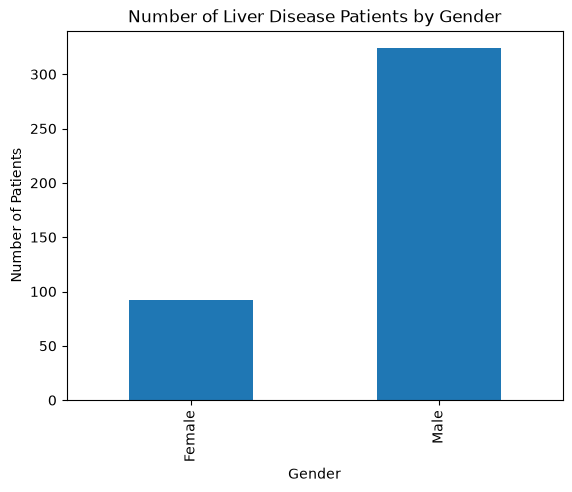

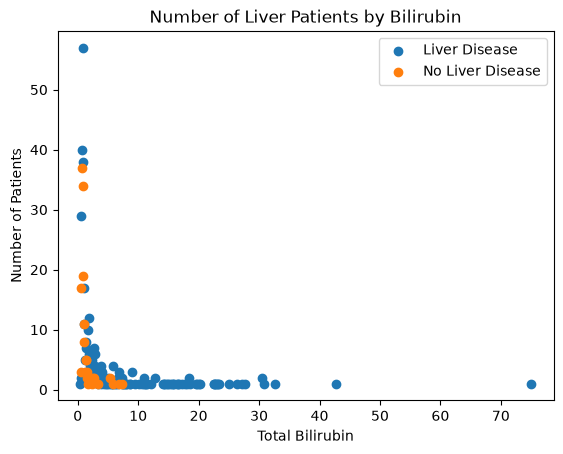

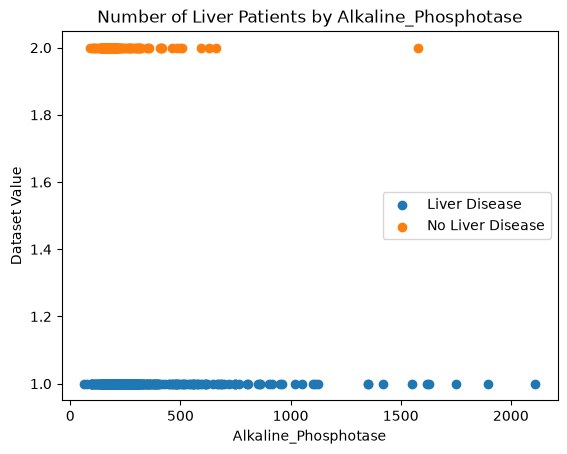

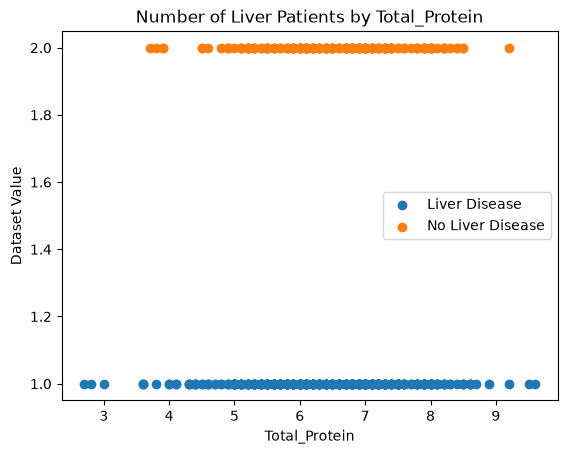

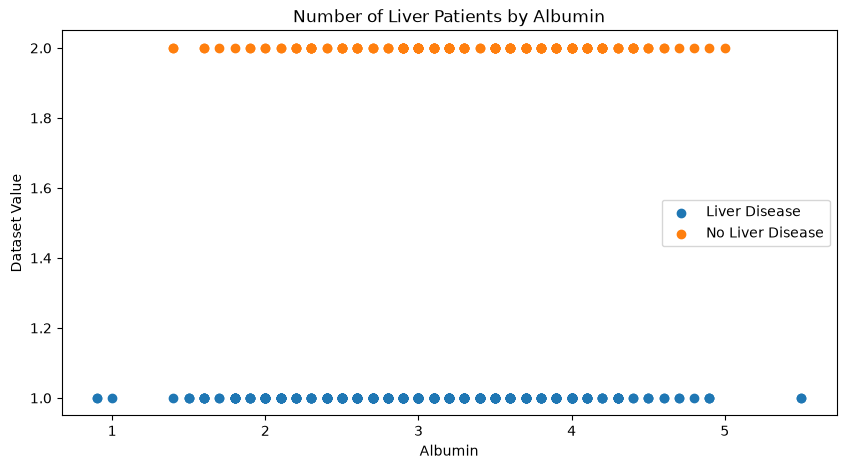

In [2]:
import matplotlib.pyplot as plt

# Create some plots to see how some columns correlate with disease
# Data shows that fewer disease patients are young
age_plot = df.iloc[df['Dataset']==1].groupby('Age')[['Dataset']].count().reset_index() # Queried ChatGPT to find out I needed to reset_index
age_plot.plot(x='Age',y='Dataset', kind='scatter', title='Number of Liver Disease Patients by Age', ylabel='Number of Patients')

# # Data shows that most disease patients are males, could be biased dataset though
gender_plot = df.iloc[df['Dataset']==1].groupby('Gender')[['Dataset']].count().reset_index()
gender_plot.plot(x='Gender', y='Dataset', kind='bar', title='Number of Liver Disease Patients by Gender', ylabel='Number of Patients', legend=False)

# Data shows that patients with higher bilirubin levels are more likely to have liver disease, this makes sense as the liver processes bilirubin
plt.figure()
bilirubin_plot1 = df.iloc[df['Dataset']==1].groupby('Total_Bilirubin')[['Dataset']].count().reset_index()
bilirubin_plot2 = df.iloc[df['Dataset']==2].groupby('Total_Bilirubin')[['Dataset']].count().reset_index()
plt.scatter(bilirubin_plot1['Total_Bilirubin'], bilirubin_plot1['Dataset'], label='Liver Disease')
plt.scatter(bilirubin_plot2['Total_Bilirubin'], bilirubin_plot2['Dataset'], label='No Liver Disease')
plt.xlabel('Total Bilirubin')
plt.ylabel('Number of Patients')
plt.title('Number of Liver Patients by Bilirubin')
plt.legend()
plt.show()

# Data shows that patients with higher Alkaline_Phosphotase levels are more likely to have liver disease
plt.figure()
df_disease = df.iloc[df['Dataset']==1]
df_no_disease = df.iloc[df['Dataset']==2]
plt.scatter(df_disease['Alkaline_Phosphotase'], df_disease['Dataset'], label='Liver Disease')
plt.scatter(df_no_disease['Alkaline_Phosphotase'], df_no_disease['Dataset'], label='No Liver Disease')
plt.xlabel('Alkaline_Phosphotase')
plt.ylabel('Dataset Value')
plt.title('Number of Liver Patients by Alkaline_Phosphotase')
plt.legend()
plt.show()

# Data shows that total protein does not indicate much
plt.figure()
plt.scatter(df_disease['Total_Protiens'], df_disease['Dataset'], label='Liver Disease')
plt.scatter(df_no_disease['Total_Protiens'], df_no_disease['Dataset'], label='No Liver Disease')
plt.xlabel('Total_Protein')
plt.ylabel('Dataset Value')
plt.title('Number of Liver Patients by Total_Protein')
plt.legend()
plt.show()

# Data shows that Albumin does not indicate much
plt.figure(figsize=(10,5))
plt.scatter(df_disease['Albumin'], df_disease['Dataset'], label='Liver Disease')
plt.scatter(df_no_disease['Albumin'], df_no_disease['Dataset'], label='No Liver Disease')
plt.xlabel('Albumin')
plt.ylabel('Dataset Value')
plt.title('Number of Liver Patients by Albumin')
plt.legend()
plt.show()

Bilirubin Outliers:



,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
22,62,Male,6.8,3.0,542,116,66,6.4,3.1,0.90,1
27,34,Male,6.2,3.0,240,1680,850,7.2,4.0,1.20,1
37,46,Female,14.2,7.8,374,38,77,4.3,2.0,0.80,1
...,...,...,...,...,...,...,...,...,...,...,...
572,32,Male,15.6,9.5,134,54,125,5.6,4.0,2.50,1
574,32,Male,12.1,6.0,515,48,92,6.6,2.4,0.50,1
575,32,Male,25.0,13.7,560,41,88,7.9,2.5,2.50,1
576,32,Male,15.0,8.2,289,58,80,5.3,2.2,0.70,1


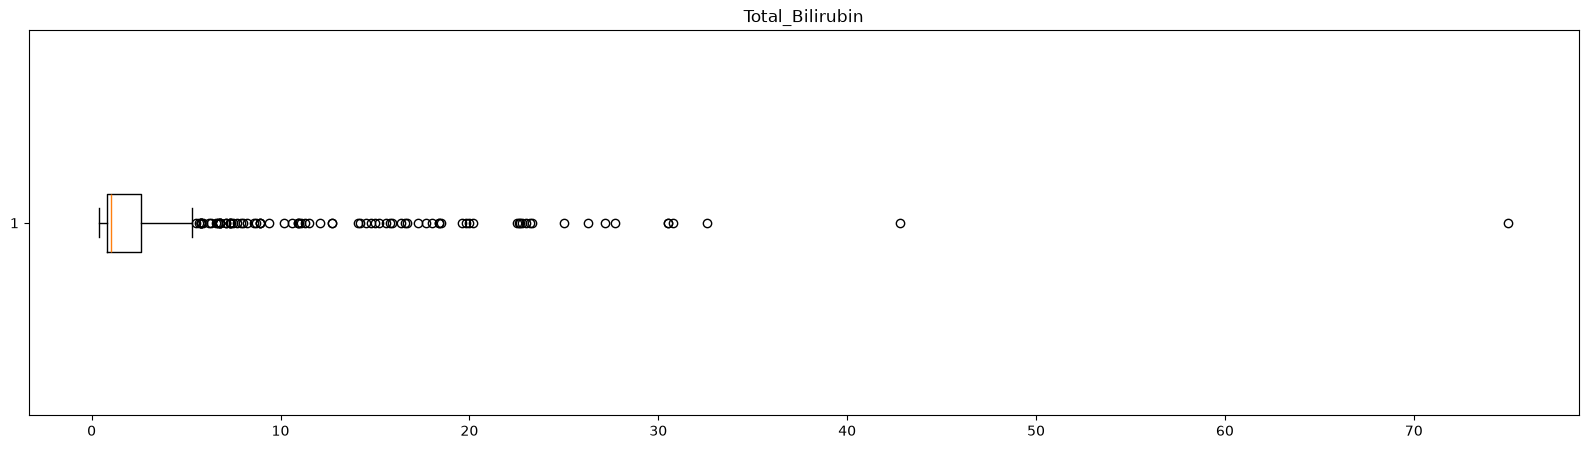

Alkaline_Phosphotase Outliers:



,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
20,51,Male,2.2,1.0,610,17,28,7.3,2.6,0.55,1
21,51,Male,2.9,1.3,482,22,34,7.0,2.4,0.50,1
22,62,Male,6.8,3.0,542,116,66,6.4,3.1,0.90,1
...,...,...,...,...,...,...,...,...,...,...,...
549,40,Female,2.1,1.0,768,74,141,7.8,4.9,1.60,1
573,32,Male,3.7,1.6,612,50,88,6.2,1.9,0.40,1
574,32,Male,12.1,6.0,515,48,92,6.6,2.4,0.50,1
575,32,Male,25.0,13.7,560,41,88,7.9,2.5,2.50,1


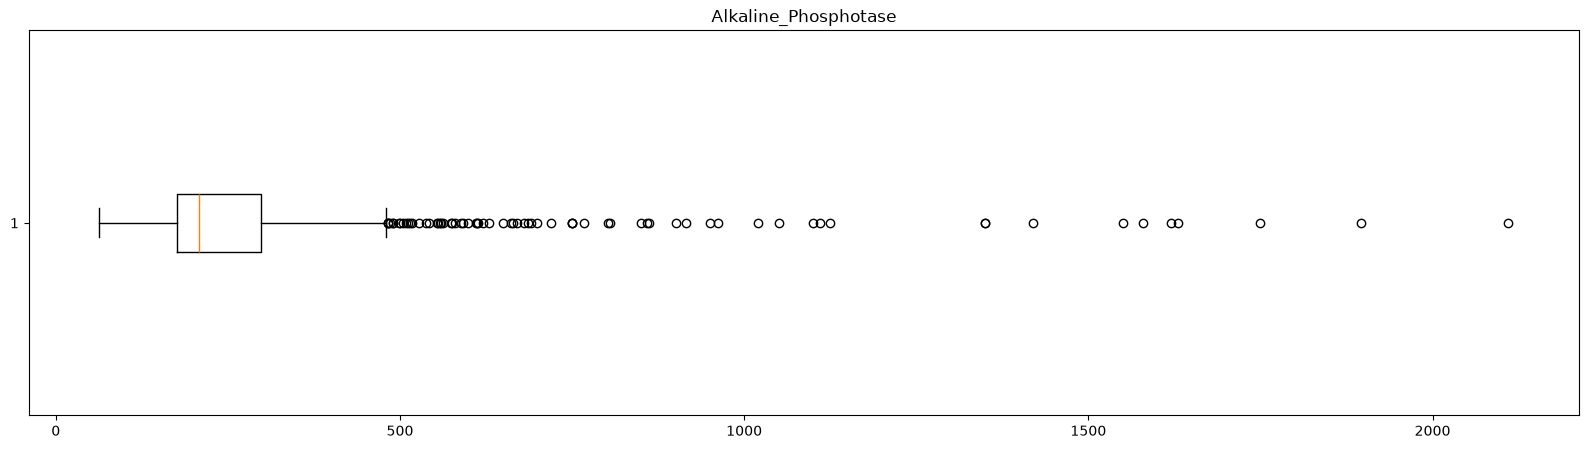

Alamine_Aminotransferase Outliers:



,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
16,38,Male,1.8,0.8,342,168,441,7.6,4.4,1.3,1
18,40,Female,0.9,0.3,293,232,245,6.8,3.1,0.8,1
19,40,Female,0.9,0.3,293,232,245,6.8,3.1,0.8,1
25,34,Male,4.1,2.0,289,875,731,5.0,2.7,1.1,1
26,34,Male,4.1,2.0,289,875,731,5.0,2.7,1.1,1
...,...,...,...,...,...,...,...,...,...,...,...
560,66,Male,15.2,7.7,356,321,562,6.5,2.2,0.4,1
561,66,Male,16.6,7.6,315,233,384,6.9,2.0,0.4,1
562,66,Male,17.3,8.5,388,173,367,7.8,2.6,0.5,1
569,16,Male,7.7,4.1,268,213,168,7.1,4.0,1.2,1


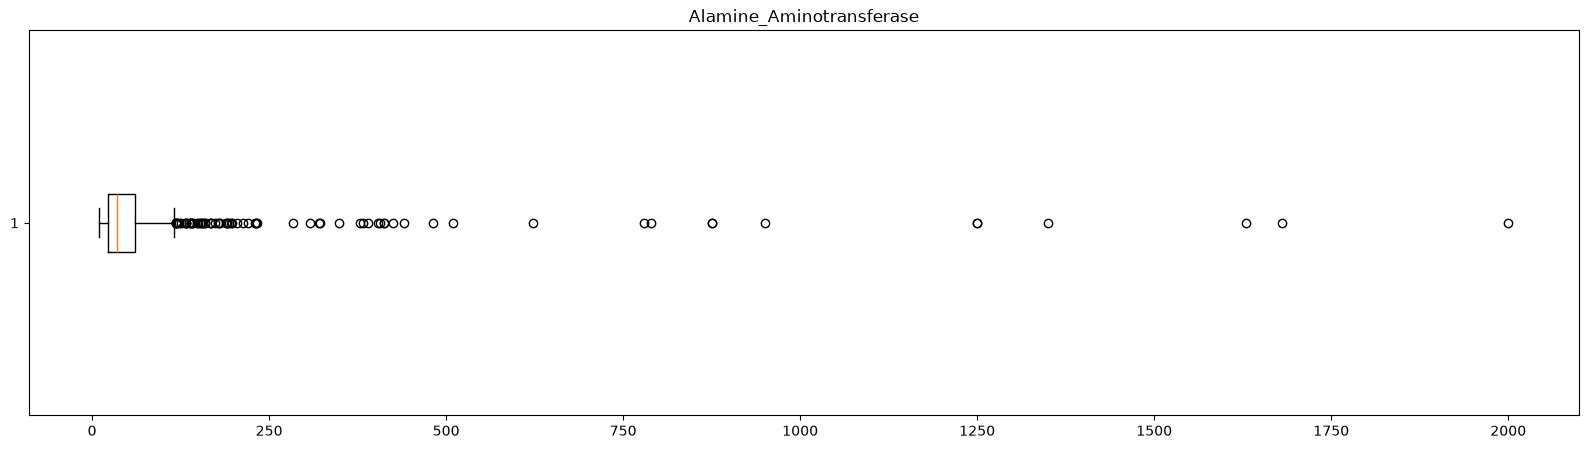

Total_Protiens Outliers:



,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
180,75,Male,2.8,1.3,250,23,29,2.7,0.9,0.5,1
181,75,Male,2.9,1.3,218,33,37,3.0,1.5,1.0,1
269,26,Male,0.6,0.1,110,15,20,2.8,1.6,1.3,1
270,37,Male,0.7,0.2,235,96,54,9.5,4.9,1.0,1
273,30,Male,0.7,0.2,262,15,18,9.6,4.7,1.2,1
415,70,Male,1.3,0.3,690,93,40,3.6,2.7,0.7,1
458,26,Male,6.8,3.2,140,37,19,3.6,0.9,0.3,1
533,46,Female,1.4,0.4,298,509,623,3.6,1.0,0.3,1


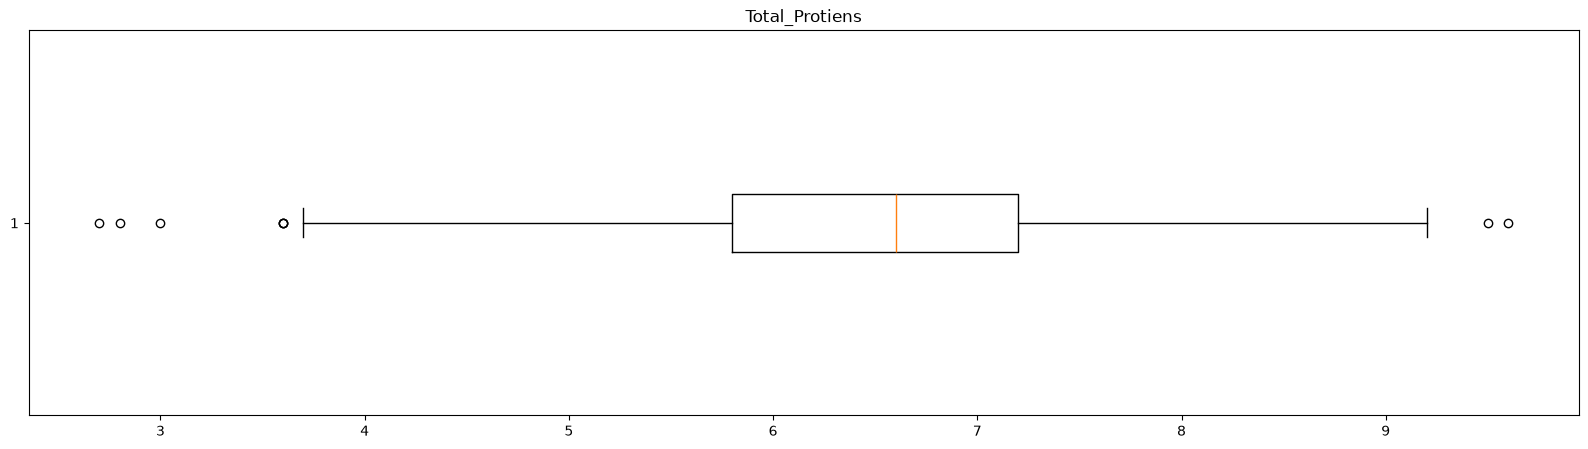

In [3]:
import numpy as np

# Detect anomalies with IQR, Total bilirubin
Q1 = df['Total_Bilirubin'].quantile(0.25)
Q3 = df['Total_Bilirubin'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
bilirubin_outliers = df[(df['Total_Bilirubin'] < lower) | (df['Total_Bilirubin'] > upper)]
print("Bilirubin Outliers:\n")
display(bilirubin_outliers)
fig, ax = plt.subplots(figsize=(20,5))
ax.boxplot(df['Total_Bilirubin'], orientation='horizontal')
ax.set_title('Total_Bilirubin')
plt.show()

# Alkaline Phosphotase
Q1 = df['Alkaline_Phosphotase'].quantile(0.25)
Q3 = df['Alkaline_Phosphotase'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
alkaline_phosphotase_outliers = df[(df['Alkaline_Phosphotase'] < lower) | (df['Alkaline_Phosphotase'] > upper)]
print("Alkaline_Phosphotase Outliers:\n")
display(alkaline_phosphotase_outliers)
fig, ax = plt.subplots(figsize=(20,5))
ax.boxplot(df['Alkaline_Phosphotase'], orientation='horizontal')
ax.set_title('Alkaline_Phosphotase')
plt.show()

# Alamine_Aminotransferase
Q1 = df['Alamine_Aminotransferase'].quantile(0.25)
Q3 = df['Alamine_Aminotransferase'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
alamine_aminotransferase_outliers = df[(df['Alamine_Aminotransferase'] < lower) | (df['Alamine_Aminotransferase'] > upper)]
print("Alamine_Aminotransferase Outliers:\n")
display(alamine_aminotransferase_outliers)
fig, ax = plt.subplots(figsize=(20,5))
ax.boxplot(df['Alamine_Aminotransferase'], orientation='horizontal')
ax.set_title('Alamine_Aminotransferase')
plt.show()

# Total_Protiens
Q1 = df['Total_Protiens'].quantile(0.25)
Q3 = df['Total_Protiens'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
total_protiens_outliers = df[(df['Total_Protiens'] < lower) | (df['Total_Protiens'] > upper)]
print("Total_Protiens Outliers:\n")
display(total_protiens_outliers)
fig, ax = plt.subplots(figsize=(20,5))
ax.boxplot(df['Total_Protiens'], orientation='horizontal')
ax.set_title('Total_Protiens')
plt.show()

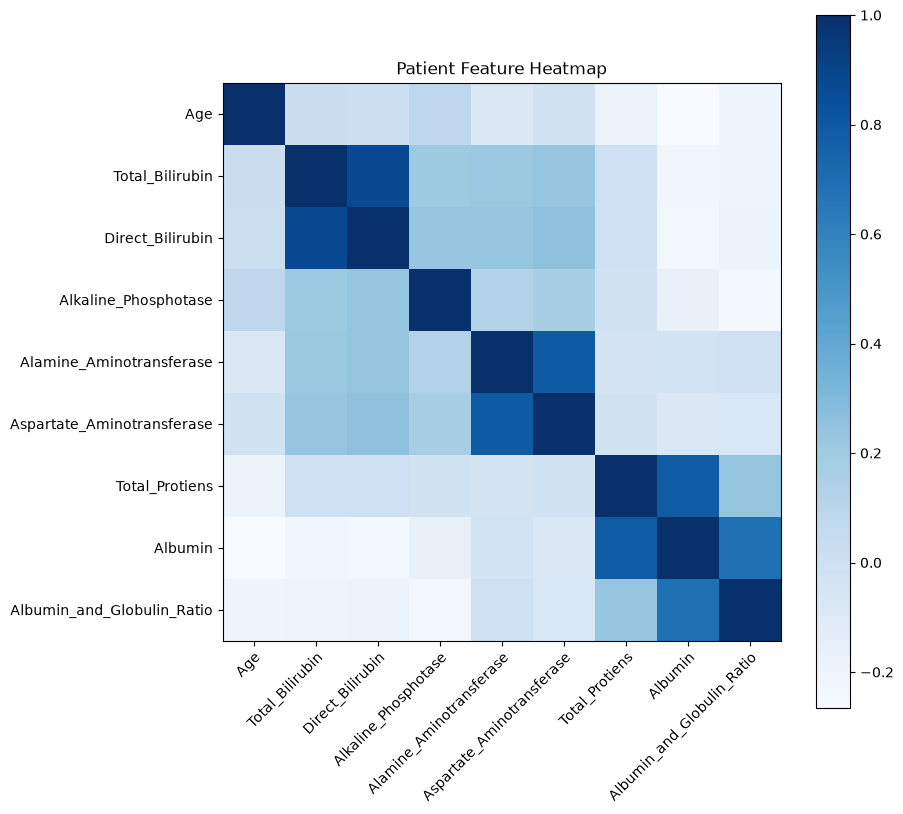

In [4]:
# Create a heatmap to check correlation between features, I used YouTube and Google's AI overview for syntax/formatting help
numerical_df = df.drop(['Gender', 'Dataset'], axis=1)
corr_df = numerical_df.corr()

fig = plt.figure(figsize=(9,9))
plt.imshow(corr_df, cmap='Blues')
plt.colorbar()
plt.xticks(range(9),corr_df.index, rotation=45, ha='right',rotation_mode='anchor')
plt.yticks(range(9),corr_df.index, ha='right',rotation_mode='anchor')
plt.title("Patient Feature Heatmap")
plt.show()

In [5]:
# Clean up the dataset

# Reduce multicollinearity as per the heat map
clean_df = df.drop(['Direct_Bilirubin','Aspartate_Aminotransferase','Albumin'],axis=1)
# Drop duplicate rows
clean_df = clean_df.drop_duplicates()
# Drop null values
clean_df = clean_df.dropna()
# Winsorize extreme values
from scipy.stats.mstats import winsorize
clean_df['Total_Bilirubin'] = winsorize(clean_df['Total_Bilirubin'],limits=[0.25, 0.25]) # Used ChatGPT to find out I can reassign easily
clean_df['Alkaline_Phosphotase'] = winsorize(clean_df['Alkaline_Phosphotase'],limits=[0.25, 0.25])
clean_df['Alamine_Aminotransferase'] = winsorize(clean_df['Alamine_Aminotransferase'],limits=[0.25, 0.25])
clean_df['Total_Protiens'] = winsorize(clean_df['Total_Protiens'],limits=[0.25, 0.25])

In [6]:
# Some features are heavily right skewed, which can negatively impact a logistic regression. Applying a log transformation
# stabalizes stabilizes the variance and reduces skewness

clean_df[['Total_Bilirubin','Alkaline_Phosphotase','Alamine_Aminotransferase']] = np.log1p(clean_df[['Total_Bilirubin','Alkaline_Phosphotase','Alamine_Aminotransferase']])

In [7]:
# Remap the target column range from [1,2] to [1,0]
clean_df['Dataset'] = 1 // clean_df['Dataset'] # 1 maps to 1 and 2 maps to 0

In [8]:
# Encode Gender column
from sklearn.preprocessing import OneHotEncoder, StandardScaler
encoder = OneHotEncoder(sparse_output=False)
encoded_gender_df = pd.DataFrame(encoder.fit_transform(clean_df[['Gender']]), columns=encoder.get_feature_names_out(['Gender']))

    # Used ChatGPT to find out that reset index matters
clean_df = pd.concat([clean_df.reset_index(drop=True), encoded_gender_df.reset_index(drop=True)], axis=1)
clean_df = clean_df.drop(['Gender'], axis=1)
# Scale all other numerical features
scaler = StandardScaler()
clean_df[['Age', 'Total_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Total_Protiens']] = scaler.fit_transform(clean_df[['Age', 'Total_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Total_Protiens']])

In [9]:
# Split the dataset to prepare for training
from sklearn.model_selection import train_test_split

df_data = pd.concat([clean_df.iloc[:,0:6],clean_df.iloc[:,7:]],axis=1)
df_target = clean_df.iloc[:,[6]]

# Note stratification due to class imbalance, i.e. there are many more rows of one class than another
X_train, X_test, y_train, y_test = train_test_split(df_data, df_target, test_size=0.2, random_state=42, stratify=df_target)

,Dataset
Dataset,
1,416
2,167


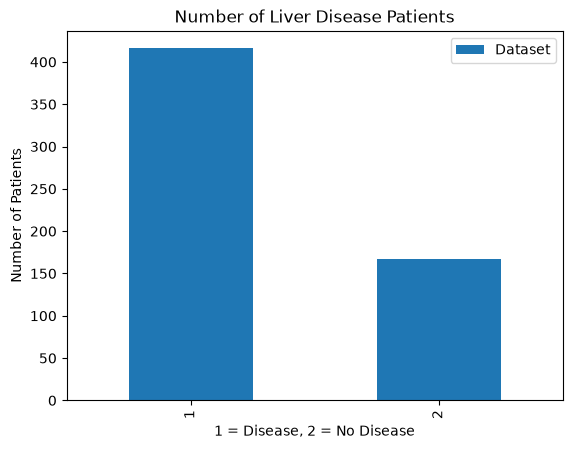

In [10]:
# Visualize the class imbalance
disease_plot = df.groupby('Dataset')[['Dataset']].count()
disease_plot.plot(kind='bar', title='Number of Liver Disease Patients', ylabel='Number of Patients', xlabel='1 = Disease, 2 = No Disease')
display(disease_plot)
plt.show()

In [11]:
# Balance the classes using SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE()
X_smote, y_smote = smote.fit_resample(X_train, y_train)

In [12]:
# Actually train a model with what we've been working towards with a logistic regression
from sklearn.linear_model import LogisticRegression

regressor = LogisticRegression(class_weight='balanced', max_iter=1000)
regressor.fit(X_smote, y_smote)

C:\Users\ferna\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [13]:
# Now make our predicitions with the trained model
y_pred = regressor.predict(X_test)

~~~~~~Prediction Metrics:~~~~~~
Accuracy: 0.7456140350877193
Precision: 0.8939393939393939
Recall: 0.7283950617283951
F1-Score: 0.8027210884353742


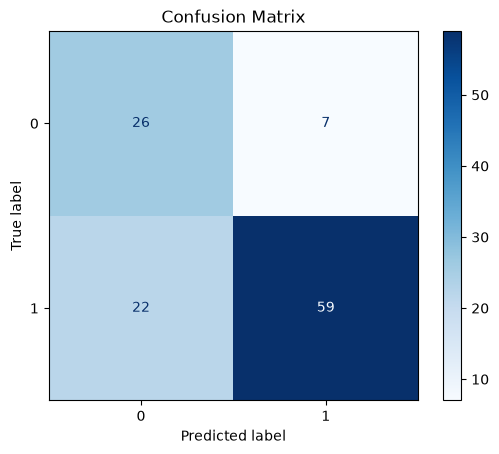

In [14]:
# Get some metrics about how the model performed
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

print("~~~~~~Prediction Metrics:~~~~~~")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues) 
plt.title("Confusion Matrix")
plt.show() 

## Part 2: Creating Some Machine Learning Concepts From Scratch

In [15]:
def sigmoid(x):
    return np.clip(1/(1+np.e**(-x)), -500, 500)

In [16]:
def cost(y_pred, y_test):
    # y_pred = pd.DataFrame(y_pred, columns=['Dataset']).reset_index(drop=True)
    # y_test = y_test.reset_index(drop=True)
    cost = 0
    m = len(y_pred)
    if m != len(y_test): return "Both vectors must be the same dimensions"
    cost = ((y_pred - y_test)**2).sum()
    return np.clip(cost / (2*m), 1e-15, 1 - 1e-15)

In [17]:
# Cost-Iteration Metrics for plot
cost_function_data = []

# I used ChatGPT to understand the structure (originally I had 3 for loops), but I condensed it down with proper linear algebra
# I also used Claude to help understand why it was running for so long. Pandas has a lot of overhead so converting everything to numpy did the trick :)
def gradient_descent(X_train, y_train, rate, max_iter=1000):
    X_train = X_train.values
    y_train = y_train.iloc[:, 0].values
    m, n = X_train.shape
    coef = np.zeros(n)

    model_error = cost(sigmoid(X_train @ coef), y_train)
    cost_function_data.append(model_error)
    transpose = X_train.transpose()

    for i in range(max_iter):
        predictions = sigmoid(X_train @ coef)
        errors = predictions - y_train

        # Dot product the errors with each feature column
        gradients = (rate/m) * (transpose @ errors)
        coef = coef - gradients

        # Calculate cost with adjusted coefficients and see if it changed at all, if it converged then break
        new_error = cost(sigmoid(X_train @ coef), y_train)
        cost_function_data.append(new_error)

        if ((model_error - new_error).sum() < 1e-10): 
            break
        # Otherwise update model_error
        model_error = new_error
    return coef

In [18]:
# Add an intercept term to the dataset, SMOTE already applied
X_smote['Intercept'] = [1] * X_smote.shape[0]
X_test['Intercept'] = [1] * X_test.shape[0]
X_smote # the training set

,Age,Total_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Total_Protiens,Albumin_and_Globulin_Ratio,Gender_Female,Gender_Male,Intercept
0,0.314447,1.434813,1.326251,1.288730,-1.256346,0.670000,0.0,1.0,1
1,-0.423537,-0.920185,-0.328981,-0.961103,1.001640,1.000000,0.0,1.0,1
2,0.252949,0.815367,-0.306919,0.679531,-1.256346,1.100000,0.0,1.0,1
3,-0.915526,-0.920185,-1.097110,-0.961103,1.175331,1.300000,1.0,0.0,1
4,-1.346017,-0.396451,-0.721119,0.021349,1.175331,1.200000,0.0,1.0,1
...,...,...,...,...,...,...,...,...,...
641,-2.438077,-0.920185,1.238486,0.543117,-0.795878,0.775745,0.0,1.0,1
642,-0.642354,-0.920185,-1.097110,-1.168324,-1.144455,0.793258,1.0,0.0,1
643,0.160586,0.531206,1.092733,1.074424,1.053128,1.070357,0.0,1.0,1
644,0.807664,-0.920185,-1.097110,-1.112250,-0.051132,1.093883,1.0,0.0,1


In [19]:
# Train the model with the gradient descent function
coef = gradient_descent(X_smote, y_smote, rate=0.01, max_iter=1000)
display(coef)

array([0.28375401, 0.46793875, 0.37279198, 0.35350671, 0.09336816,
       0.02836134, 0.07793737, 0.04858694, 0.12652431])

In [20]:
# Predict with the trained model
y_pred_scratch = np.floor(sigmoid(X_test @ coef).reset_index(drop=True) * 2)
display(y_pred_scratch)

0      1.0
1      1.0
2      1.0
3      0.0
4      1.0
      ... 
109    0.0
110    1.0
111    1.0
112    1.0
113    1.0
Length: 114, dtype: float64

~~~~~~Prediction Metrics:~~~~~~
Accuracy: 0.7543859649122807
Precision: 0.9076923076923077
Recall: 0.7283950617283951
F1-Score: 0.8082191780821918


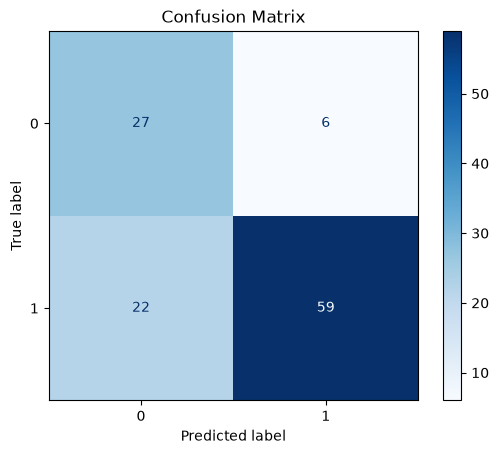

In [21]:
# Evaluation metrics (looks good!)
print("~~~~~~Prediction Metrics:~~~~~~")
print("Accuracy:", accuracy_score(y_test, y_pred_scratch))
print("Precision:", precision_score(y_test, y_pred_scratch))
print("Recall:", recall_score(y_test, y_pred_scratch))
print("F1-Score:", f1_score(y_test, y_pred_scratch))

cm = confusion_matrix(y_test, y_pred_scratch)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues) 
plt.title("Confusion Matrix")
plt.show() 

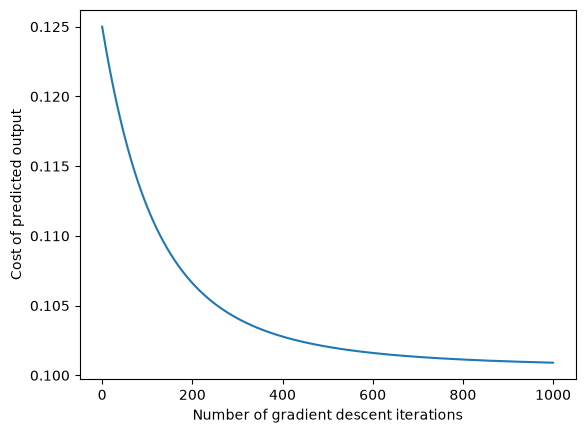

In [22]:
plt.figure()
plt.plot(cost_function_data,)
plt.xlabel("Number of gradient descent iterations")
plt.ylabel("Cost of predicted output")
plt.show()